In [ ]:
import os
from pathlib import Path

# Path lokal (macOS) atau Kaggle — otomatis pilih yang tersedia
_LOCAL = Path("/Users/jae/Developer/FINDIT/data/kaggle/search-and-rescue")
_KAGGLE = Path("/kaggle/input/datasets/nikolasgegenava/sard-search-and-rescue/search-and-rescue")
dataset_root = _KAGGLE if _KAGGLE.exists() else _LOCAL

print(f"📂 dataset_root: {dataset_root}")
print(f"   Exists: {dataset_root.exists()}")

# =============================================
# CELL 1: Eksplorasi Struktur Dataset
# =============================================

print("\n" + "=" * 50)
print("📁 STRUKTUR DATASET")
print("=" * 50)

total_images = 0
total_labels = 0
split_summary = {}

for split in ["train", "valid", "test"]:
    img_dir = dataset_root / split / "images"
    lbl_dir = dataset_root / split / "labels"

    imgs = list(img_dir.glob("*.*")) if img_dir.exists() else []
    lbls = list(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []

    # Cek gambar tanpa label dan sebaliknya
    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}
    missing_labels = img_stems - lbl_stems
    missing_images = lbl_stems - img_stems

    split_summary[split] = {
        "images": len(imgs),
        "labels": len(lbls),
        "missing_labels": len(missing_labels),
        "missing_images": len(missing_images)
    }

    total_images += len(imgs)
    total_labels += len(lbls)

    print(f"\n  📂 {split.upper()}")
    print(f"     Images : {len(imgs)}")
    print(f"     Labels : {len(lbls)}")
    if missing_labels:
        print(f"     ⚠️  Gambar tanpa label : {len(missing_labels)}")
    if missing_images:
        print(f"     ⚠️  Label tanpa gambar : {len(missing_images)}")

print(f"\n{'=' * 50}")
print(f"  TOTAL Images : {total_images}")
print(f"  TOTAL Labels : {total_labels}")
print(f"{'=' * 50}")

# Cek format gambar
print("\n📸 FORMAT GAMBAR:")
all_exts = {}
for split in ["train", "valid", "test"]:
    img_dir = dataset_root / split / "images"
    if img_dir.exists():
        for f in img_dir.glob("*.*"):
            ext = f.suffix.lower()
            all_exts[ext] = all_exts.get(ext, 0) + 1

for ext, count in sorted(all_exts.items(), key=lambda x: -x[1]):
    print(f"  {ext}: {count} files")


📂 dataset_root: /kaggle/input/datasets/nikolasgegenava/sard-search-and-rescue/search-and-rescue
   Exists: True

📁 STRUKTUR DATASET

  📂 TRAIN
     Images : 4041
     Labels : 4041

  📂 VALID
     Images : 1144
     Labels : 1144

  📂 TEST
     Images : 570
     Labels : 570

  TOTAL Images : 5755
  TOTAL Labels : 5755

📸 FORMAT GAMBAR:
  .jpg: 5755 files


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

# =============================================
# CELL 2: Analisis Label & Distribusi Kelas
# =============================================

print("=" * 50)
print("🏷️  ANALISIS LABEL (YOLO FORMAT)")
print("=" * 50)

class_names = ["human"]
all_annotations = {}  # {split: [{class_id, cx, cy, w, h}, ...]}
objects_per_image = {}  # {split: [count, ...]}
class_counts = {}  # {split: {class_id: count}}

for split in ["train", "valid", "test"]:
    lbl_dir = dataset_root / split / "labels"
    annotations = []
    counts_per_img = []
    cls_cnt = {}

    if lbl_dir.exists():
        for lbl_file in lbl_dir.glob("*.txt"):
            with open(lbl_file) as f:
                lines = f.read().strip().splitlines()
            n = 0
            for line in lines:
                if line.strip():
                    parts = line.strip().split()
                    cls_id = int(parts[0])
                    cx, cy, w, h = map(float, parts[1:5])
                    annotations.append({"class_id": cls_id, "cx": cx, "cy": cy, "w": w, "h": h})
                    cls_cnt[cls_id] = cls_cnt.get(cls_id, 0) + 1
                    n += 1
            counts_per_img.append(n)

    all_annotations[split] = annotations
    objects_per_image[split] = counts_per_img
    class_counts[split] = cls_cnt

    total_obj = len(annotations)
    img_with_obj = sum(1 for c in counts_per_img if c > 0)
    img_empty = sum(1 for c in counts_per_img if c == 0)
    avg_obj = np.mean(counts_per_img) if counts_per_img else 0

    print(f"\n  📂 {split.upper()}")
    print(f"     Total objek      : {total_obj}")
    print(f"     Gambar berisi obj: {img_with_obj}")
    print(f"     Gambar kosong    : {img_empty}")
    print(f"     Rata-rata obj/img: {avg_obj:.2f}")
    if cls_cnt:
        for cid, cnt in sorted(cls_cnt.items()):
            cname = class_names[cid] if cid < len(class_names) else f"class_{cid}"
            print(f"     [{cid}] {cname}: {cnt} objek")


🏷️  ANALISIS LABEL (YOLO FORMAT)

  📂 TRAIN
     Total objek      : 5229
     Gambar berisi obj: 3470
     Gambar kosong    : 571
     Rata-rata obj/img: 1.29
     [0] human: 5229 objek

  📂 TRAIN
     Total objek      : 5229
     Gambar berisi obj: 3470
     Gambar kosong    : 571
     Rata-rata obj/img: 1.29
     [0] human: 5229 objek

  📂 VALID
     Total objek      : 1463
     Gambar berisi obj: 967
     Gambar kosong    : 177
     Rata-rata obj/img: 1.28
     [0] human: 1463 objek

  📂 VALID
     Total objek      : 1463
     Gambar berisi obj: 967
     Gambar kosong    : 177
     Rata-rata obj/img: 1.28
     [0] human: 1463 objek

  📂 TEST
     Total objek      : 732
     Gambar berisi obj: 486
     Gambar kosong    : 84
     Rata-rata obj/img: 1.28
     [0] human: 732 objek

  📂 TEST
     Total objek      : 732
     Gambar berisi obj: 486
     Gambar kosong    : 84
     Rata-rata obj/img: 1.28
     [0] human: 732 objek


/tmp/ipykernel_55/3686923811.py:35: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


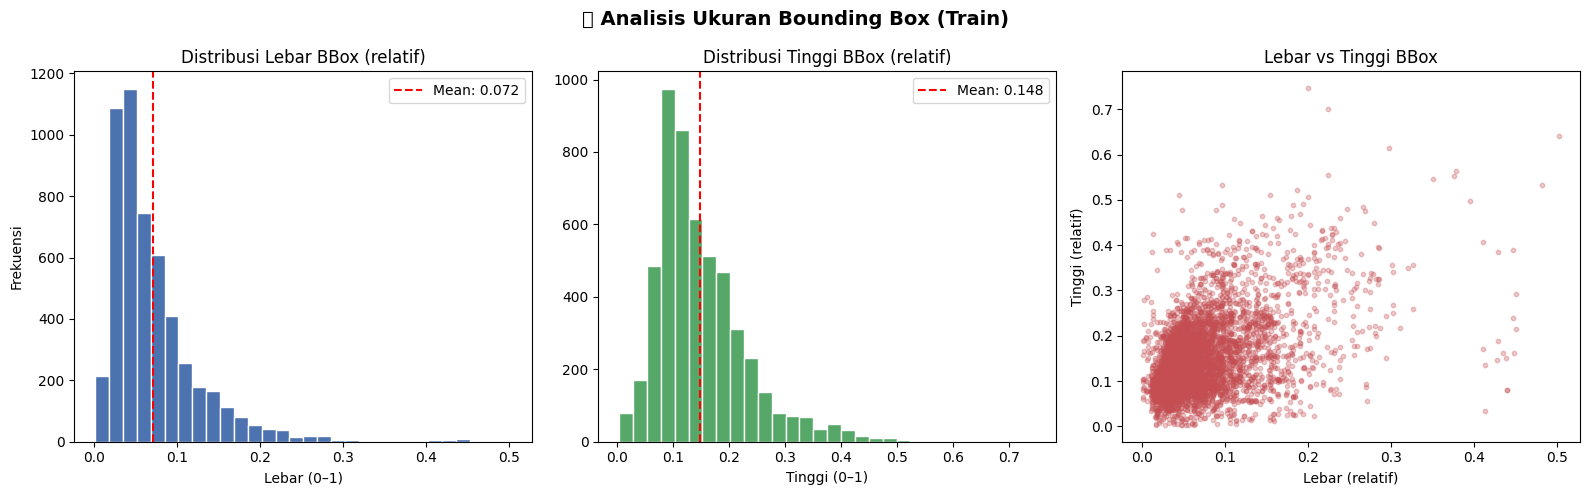


📊 Statistik BBox (Train):
  Lebar   — min: 0.0016, max: 0.5031, mean: 0.0715, median: 0.0563
  Tinggi  — min: 0.0031, max: 0.7469, mean: 0.1482, median: 0.1281
  Area    — min: 0.000054, max: 0.322708, mean: 0.012699


In [19]:
# =============================================
# CELL 4: Analisis Ukuran Bounding Box
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("📐 Analisis Ukuran Bounding Box (Train)", fontsize=14, fontweight="bold")

train_ann = all_annotations["train"]
if train_ann:
    widths  = [a["w"] for a in train_ann]
    heights = [a["h"] for a in train_ann]
    areas   = [a["w"] * a["h"] for a in train_ann]

    # Histogram width
    axes[0].hist(widths, bins=30, color="#4C72B0", edgecolor="white")
    axes[0].set_title("Distribusi Lebar BBox (relatif)")
    axes[0].set_xlabel("Lebar (0–1)")
    axes[0].set_ylabel("Frekuensi")
    axes[0].axvline(np.mean(widths), color="red", linestyle="--", label=f"Mean: {np.mean(widths):.3f}")
    axes[0].legend()

    # Histogram height
    axes[1].hist(heights, bins=30, color="#55A868", edgecolor="white")
    axes[1].set_title("Distribusi Tinggi BBox (relatif)")
    axes[1].set_xlabel("Tinggi (0–1)")
    axes[1].axvline(np.mean(heights), color="red", linestyle="--", label=f"Mean: {np.mean(heights):.3f}")
    axes[1].legend()

    # Scatter width vs height
    axes[2].scatter(widths, heights, alpha=0.3, s=10, color="#C44E52")
    axes[2].set_title("Lebar vs Tinggi BBox")
    axes[2].set_xlabel("Lebar (relatif)")
    axes[2].set_ylabel("Tinggi (relatif)")

    plt.tight_layout()
    plt.show()

    print(f"\n📊 Statistik BBox (Train):")
    print(f"  Lebar   — min: {min(widths):.4f}, max: {max(widths):.4f}, mean: {np.mean(widths):.4f}, median: {np.median(widths):.4f}")
    print(f"  Tinggi  — min: {min(heights):.4f}, max: {max(heights):.4f}, mean: {np.mean(heights):.4f}, median: {np.median(heights):.4f}")
    print(f"  Area    — min: {min(areas):.6f}, max: {max(areas):.6f}, mean: {np.mean(areas):.6f}")


/tmp/ipykernel_55/1148405442.py:24: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


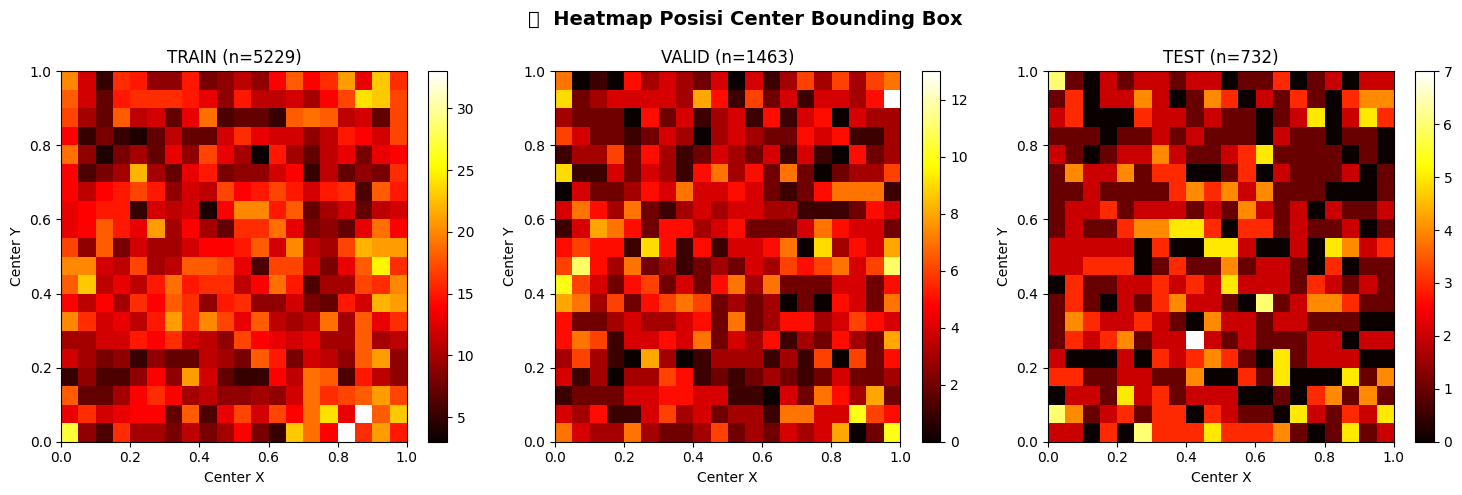

✅ Heatmap posisi bbox selesai


In [20]:
# =============================================
# CELL 5: Heatmap Posisi Center BBox
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("🗺️  Heatmap Posisi Center Bounding Box", fontsize=14, fontweight="bold")

for idx, split in enumerate(["train", "valid", "test"]):
    ann = all_annotations[split]
    if ann:
        cx_vals = [a["cx"] for a in ann]
        cy_vals = [a["cy"] for a in ann]
        h, xedges, yedges = np.histogram2d(cx_vals, cy_vals, bins=20, range=[[0,1],[0,1]])
        im = axes[idx].imshow(h.T, origin="lower", extent=[0,1,0,1],
                              cmap="hot", aspect="auto")
        axes[idx].set_title(f"{split.upper()} (n={len(ann)})")
        axes[idx].set_xlabel("Center X")
        axes[idx].set_ylabel("Center Y")
        plt.colorbar(im, ax=axes[idx])
    else:
        axes[idx].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")
        axes[idx].set_title(split.upper())

plt.tight_layout()
plt.show()
print("✅ Heatmap posisi bbox selesai")


In [21]:
# =============================================
# CELL 6: Analisis Ukuran Gambar
# =============================================

print("=" * 50)
print("🖼️  ANALISIS UKURAN GAMBAR")
print("=" * 50)

img_sizes = {}
for split in ["train", "valid", "test"]:
    img_dir = dataset_root / split / "images"
    sizes = []
    if img_dir.exists():
        img_files = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        sample = random.sample(img_files, min(50, len(img_files)))
        for f in sample:
            try:
                with Image.open(f) as img:
                    sizes.append(img.size)  # (W, H)
            except Exception:
                pass
    img_sizes[split] = sizes

for split in ["train", "valid", "test"]:
    sizes = img_sizes[split]
    if sizes:
        widths  = [s[0] for s in sizes]
        heights = [s[1] for s in sizes]
        unique  = set(sizes)
        print(f"\n  📂 {split.upper()} (sample {len(sizes)} gambar)")
        print(f"     Ukuran unik : {len(unique)}")
        print(f"     Lebar  : {min(widths)}–{max(widths)} px (mean {np.mean(widths):.0f})")
        print(f"     Tinggi : {min(heights)}–{max(heights)} px (mean {np.mean(heights):.0f})")
        if len(unique) <= 3:
            print(f"     Ukuran : {unique}")


🖼️  ANALISIS UKURAN GAMBAR

  📂 TRAIN (sample 50 gambar)
     Ukuran unik : 1
     Lebar  : 640–640 px (mean 640)
     Tinggi : 640–640 px (mean 640)
     Ukuran : {(640, 640)}

  📂 VALID (sample 50 gambar)
     Ukuran unik : 1
     Lebar  : 640–640 px (mean 640)
     Tinggi : 640–640 px (mean 640)
     Ukuran : {(640, 640)}

  📂 TEST (sample 50 gambar)
     Ukuran unik : 1
     Lebar  : 640–640 px (mean 640)
     Tinggi : 640–640 px (mean 640)
     Ukuran : {(640, 640)}

  📂 TRAIN (sample 50 gambar)
     Ukuran unik : 1
     Lebar  : 640–640 px (mean 640)
     Tinggi : 640–640 px (mean 640)
     Ukuran : {(640, 640)}

  📂 VALID (sample 50 gambar)
     Ukuran unik : 1
     Lebar  : 640–640 px (mean 640)
     Tinggi : 640–640 px (mean 640)
     Ukuran : {(640, 640)}

  📂 TEST (sample 50 gambar)
     Ukuran unik : 1
     Lebar  : 640–640 px (mean 640)
     Tinggi : 640–640 px (mean 640)
     Ukuran : {(640, 640)}


/tmp/ipykernel_55/2848566081.py:53: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


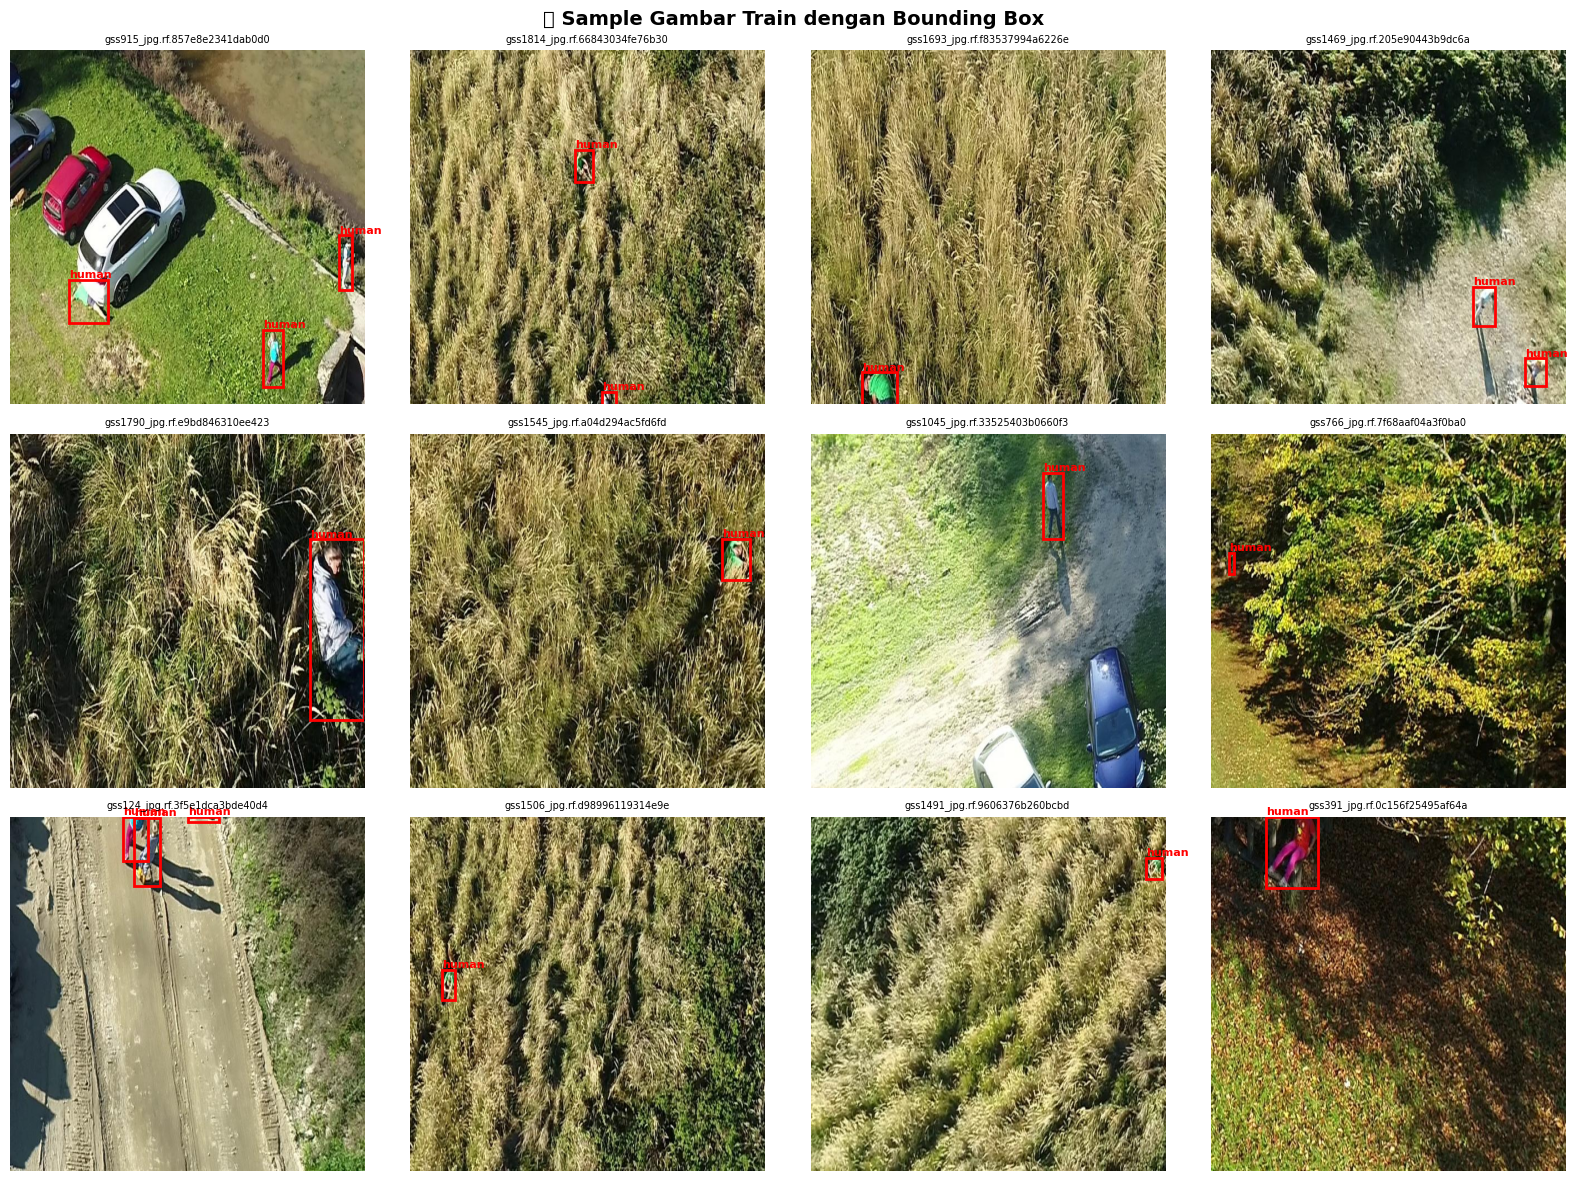

✅ Sample visualisasi bounding box selesai


In [22]:
# =============================================
# CELL 7: Visualisasi Sample Gambar + Bounding Box
# =============================================

def draw_bbox_on_image(img_path, lbl_path, ax, class_names=["human"]):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name[:30], fontsize=7)

    colors_map = ["red", "blue", "green", "orange", "purple"]
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                cx, cy, w, h = map(float, parts[1:5])
                x1 = (cx - w / 2) * W
                y1 = (cy - h / 2) * H
                bw = w * W
                bh = h * H
                color = colors_map[cls_id % len(colors_map)]
                rect = patches.Rectangle((x1, y1), bw, bh,
                                          linewidth=2, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                label = class_names[cls_id] if cls_id < len(class_names) else f"cls{cls_id}"
                ax.text(x1, y1 - 3, label, color=color, fontsize=8, fontweight="bold")

# Tampilkan 12 sample dari train
train_img_dir = dataset_root / "train" / "images"
train_lbl_dir = dataset_root / "train" / "labels"
img_files = list(train_img_dir.glob("*.jpg"))

# Prioritaskan gambar yang punya bounding box
labeled = [f for f in img_files if (train_lbl_dir / (f.stem + ".txt")).exists()
           and (train_lbl_dir / (f.stem + ".txt")).stat().st_size > 0]
sample_files = random.sample(labeled, min(12, len(labeled)))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle("🔍 Sample Gambar Train dengan Bounding Box", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, img_path in enumerate(sample_files):
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    draw_bbox_on_image(img_path, lbl_path, axes[i])

for j in range(len(sample_files), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
print("✅ Sample visualisasi bounding box selesai")


In [ ]:
# =============================================
# CELL 8: Ringkasan EDA
# =============================================

print("=" * 55)
print("📋  RINGKASAN EDA — SEARCH & RESCUE DATASET")
print("=" * 55)

total_obj_all = sum(len(all_annotations[s]) for s in ["train", "valid", "test"])
all_widths  = [a["w"] for s in ["train","valid","test"] for a in all_annotations[s]]
all_heights = [a["h"] for s in ["train","valid","test"] for a in all_annotations[s]]

print(f"\n  Dataset   : Search and Rescue (Roboflow)")
print(f"  Kelas     : {', '.join(class_names)} (nc=1)")
print(f"\n  ── Jumlah Data ──")
for s in ["train", "valid", "test"]:
    print(f"  {s.upper():6s} : {split_summary[s]['images']:5d} gambar | {len(all_annotations[s]):5d} objek")
print(f"  {'TOTAL':6s} : {total_images:5d} gambar | {total_obj_all:5d} objek")

print(f"\n  ── Statistik Bounding Box (semua split) ──")
if all_widths:
    print(f"  Lebar  bbox : mean={np.mean(all_widths):.4f}, std={np.std(all_widths):.4f}")
    print(f"  Tinggi bbox : mean={np.mean(all_heights):.4f}, std={np.std(all_heights):.4f}")
    small  = sum(1 for w,h in zip(all_widths,all_heights) if w*h < 0.01)
    medium = sum(1 for w,h in zip(all_widths,all_heights) if 0.01 <= w*h < 0.1)
    large  = sum(1 for w,h in zip(all_widths,all_heights) if w*h >= 0.1)
    total_boxes = len(all_widths)
    print(f"\n  ── Ukuran Objek ──")
    print(f"  Kecil  (area < 1%)   : {small:5d} ({100*small/total_boxes:.1f}%)")
    print(f"  Sedang (1%–10% area) : {medium:5d} ({100*medium/total_boxes:.1f}%)")
    print(f"  Besar  (area > 10%)  : {large:5d} ({100*large/total_boxes:.1f}%)")

print("\n" + "=" * 55)
print("✅  EDA selesai!")
print("=" * 55)


/tmp/ipykernel_55/2005937068.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


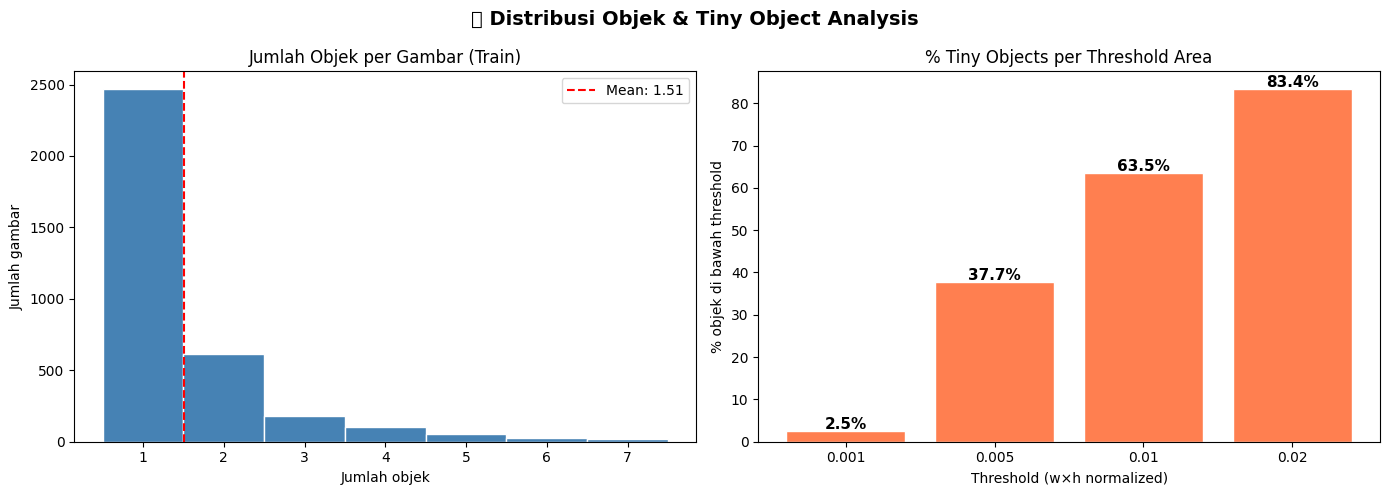


🔍 Tiny Object Summary (Train):
   Area < 0.001: 129 objek (2.5%)
   Area < 0.005: 1971 objek (37.7%)
   Area < 0.01: 3320 objek (63.5%)
   Area < 0.02: 4360 objek (83.4%)


In [26]:

# =============================================
# CELL 9: Distribusi Objek per Gambar + Tiny Object Analysis
# =============================================
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📊 Distribusi Objek & Tiny Object Analysis", fontsize=14, fontweight='bold')

# Plot 1: Objek per gambar (dari objects_per_image)
train_counts = objects_per_image["train"]
counts = [c for c in train_counts if c > 0]  # hanya gambar yang ada objeknya

if counts:
    axes[0].hist(counts, bins=range(1, max(counts)+2), color='steelblue',
                 edgecolor='white', align='left')
    axes[0].set_title("Jumlah Objek per Gambar (Train)")
    axes[0].set_xlabel("Jumlah objek")
    axes[0].set_ylabel("Jumlah gambar")
    axes[0].axvline(np.mean(counts), color='red', linestyle='--',
                    label=f'Mean: {np.mean(counts):.2f}')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, "Tidak ada data", ha="center", va="center")

# Plot 2: Tiny object analysis
train_ann = all_annotations["train"]
areas = [a["w"] * a["h"] for a in train_ann]
thresholds = [0.001, 0.005, 0.01, 0.02]
tiny_pcts = [(np.array(areas) < t).mean() * 100 for t in thresholds]

axes[1].bar([str(t) for t in thresholds], tiny_pcts, color='coral', edgecolor='white')
axes[1].set_title("% Tiny Objects per Threshold Area")
axes[1].set_xlabel("Threshold (w×h normalized)")
axes[1].set_ylabel("% objek di bawah threshold")
for bar, val in zip(axes[1].patches, tiny_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detail
print(f"\n🔍 Tiny Object Summary (Train):")
for t, pct in zip(thresholds, tiny_pcts):
    count = (np.array(areas) < t).sum()
    print(f"   Area < {t}: {count} objek ({pct:.1f}%)")


In [27]:
# Install dependencies
%pip install ultralytics opencv-python-headless -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.3 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ultralytics import YOLO
from pathlib import Path

# Path ke data.yaml — ikuti dataset_root yang sudah diset di Cell 1
data_yaml = str(dataset_root / "data.yaml")
print(f"📂 data.yaml path: {data_yaml}")
print(f"   Exists: {Path(data_yaml).exists()}")

# =============================================
# ⚠️  TRAINING — Jalankan di Kaggle / GPU environment
# =============================================
# Di lokal (CPU), training 100 epoch imgsz=1280 akan sangat lama.
# Uncomment baris di bawah saat siap training penuh (Kaggle/Colab/GPU).

RUN_TRAINING = False  # ← set True untuk mulai training

if RUN_TRAINING:
    model = YOLO("yolov8s.pt")
    model.train(
        data=data_yaml,
        imgsz=1280,          # besar untuk preserve detail objek kecil
        epochs=100,
        batch=8,
        optimizer="AdamW",
        lr0=0.001,
        weight_decay=0.0005,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,
        degrees=45,
        fliplr=0.5,
        flipud=0.3,
        mosaic=1.0,
        mixup=0.1,
        close_mosaic=10,
        project="droneaid",
        name="yolov8s_sar_run1",
        save=True,
        plots=True,
    )
else:
    # Verifikasi: load model dan cek bisa inference
    model = YOLO("yolov8s.pt")
    print(f"✅ Model loaded: {model.model.__class__.__name__}")
    print(f"✅ ultralytics OK — set RUN_TRAINING=True untuk mulai training")


: 

In [ ]:
from ultralytics import YOLO
import cv2

# Load model yang sudah ditraining
model = YOLO("droneaid/yolov8s_sar_run1/weights/best.pt")

# Buka kamera
cap = cv2.VideoCapture(0)  # 0 = webcam default, ganti dengan index lain kalau ada kamera eksternal

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Inference
    results = model(frame, imgsz=1280, conf=0.3, iou=0.5)

    # Render hasil
    annotated = results[0].plot()

    cv2.imshow("DroneAid - Live Detection", annotated)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

model = YOLO("droneaid/yolov8s_sar_run1/weights/best.pt")
cap = cv2.VideoCapture(0)

# State tracking per objek
prev_gray = None
motion_history = defaultdict(list)  # track motion per detection ID
MOTION_WINDOW = 10  # frames untuk analisis motion

# Warna per status
STATUS_COLOR = {
    "MOBILE":   (0, 255, 0),    # Hijau
    "DISTRESS": (0, 165, 255),  # Orange
    "PRONE":    (0, 0, 255),    # Merah
    "STATIC":   (128, 128, 128) # Abu
}

def classify_state(motion_mag, bbox_w, bbox_h, motion_pattern):
    ratio = bbox_w / bbox_h if bbox_h > 0 else 1.0

    if motion_mag > 2.5:
        return "MOBILE"
    elif motion_mag > 0.8 and motion_pattern == "intermittent":
        return "DISTRESS"
    elif motion_mag < 0.5 and ratio > 1.4:
        return "PRONE"
    else:
        return "STATIC"

def get_motion_pattern(history):
    if len(history) < MOTION_WINDOW:
        return "unknown"
    # Cek apakah ada pola on-off (intermittent = distress)
    above = [m > 1.0 for m in history[-MOTION_WINDOW:]]
    transitions = sum(1 for i in range(1, len(above)) if above[i] != above[i-1])
    return "intermittent" if transitions >= 3 else "consistent"

frame_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    results = model(frame, imgsz=640, conf=0.3, verbose=False)  # 640 untuk speed di live

    victim_count = {"MOBILE": 0, "DISTRESS": 0, "PRONE": 0, "STATIC": 0}

    if results[0].boxes is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = map(int, box)
            bw = (x2 - x1) / frame.shape[1]
            bh = (y2 - y1) / frame.shape[0]

            # Optical flow di dalam bounding box
            motion_mag = 0.0
            if prev_gray is not None:
                roi_prev = prev_gray[y1:y2, x1:x2]
                roi_curr = gray[y1:y2, x1:x2]
                if roi_prev.shape == roi_curr.shape and roi_prev.size > 0:
                    flow = cv2.calcOpticalFlowFarneback(
                        roi_prev, roi_curr, None,
                        0.5, 3, 15, 3, 5, 1.2, 0
                    )
                    motion_mag = np.mean(np.sqrt(flow[...,0]**2 + flow[...,1]**2))

            # Update history
            motion_history[i].append(motion_mag)
            if len(motion_history[i]) > 30:
                motion_history[i].pop(0)

            pattern = get_motion_pattern(motion_history[i])
            status = classify_state(motion_mag, bw, bh, pattern)
            victim_count[status] += 1

            # Draw
            color = STATUS_COLOR[status]
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, f"{status} ({motion_mag:.1f})",
                       (x1, y1-8), cv2.FONT_HERSHEY_SIMPLEX,
                       0.5, color, 2)

    # HUD overlay
    y_hud = 30
    for status, count in victim_count.items():
        if count > 0:
            color = STATUS_COLOR[status]
            cv2.putText(frame, f"{status}: {count}",
                       (10, y_hud), cv2.FONT_HERSHEY_SIMPLEX,
                       0.6, color, 2)
            y_hud += 25

    cv2.putText(frame, f"Frame: {frame_count}",
               (10, frame.shape[0]-10),
               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    prev_gray = gray.copy()
    frame_count += 1

    cv2.imshow("DroneAid - Live Triage", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()